In [1]:
import json
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

In [2]:
checkpoint_dir = Path("data") / "ch09"

In [3]:
json_files = sorted(
    checkpoint_dir.glob("fine-tuning_*.json"),
    key=lambda x: x.stat().st_ctime,
    #key=lambda x: int(x.name.split("-")[1]),
    reverse=False,
)

records = []
for f in json_files:
    #print(f"---> file: {f}")
    data = json.loads(f.read_text())

    epoch = f.name.replace("fine-tuning_", "").replace(".json", "")
    records.append((
        int(epoch),
        data['train_loss'],
        data['val_loss'],
        data['created_at'],
    ))

In [4]:
df = pd.DataFrame.from_records(records, columns=["epoch", "train_loss", "val_loss", "created_at"])

df = df.sort_values(by='epoch', ascending=True)

df.to_csv(checkpoint_dir / "fine-tuning.tsv", index=False, sep='\t')

In [5]:
print(df.nsmallest(1, 'train_loss'))
df.tail(10)

    epoch  train_loss  val_loss              created_at
67     68     3.17742  4.475736  2025-09-18T20:02:48%:z


,epoch,train_loss,val_loss,created_at
220,221,3.339956,4.837292,2025-09-19T10:04:22%:z
221,222,3.322046,4.793479,2025-09-19T10:05:59%:z
222,223,3.271123,4.769589,2025-09-19T10:07:37%:z
223,224,3.281103,4.790788,2025-09-19T10:09:14%:z
224,225,3.251188,4.750907,2025-09-19T10:10:52%:z
225,226,3.299699,4.791979,2025-09-19T10:12:29%:z
226,227,3.288554,4.772200,2025-09-19T10:14:06%:z
227,228,3.217437,4.671799,2025-09-19T10:15:43%:z
228,229,3.228880,4.691388,2025-09-19T10:17:21%:z
229,230,3.258974,4.695826,2025-09-19T10:18:58%:z


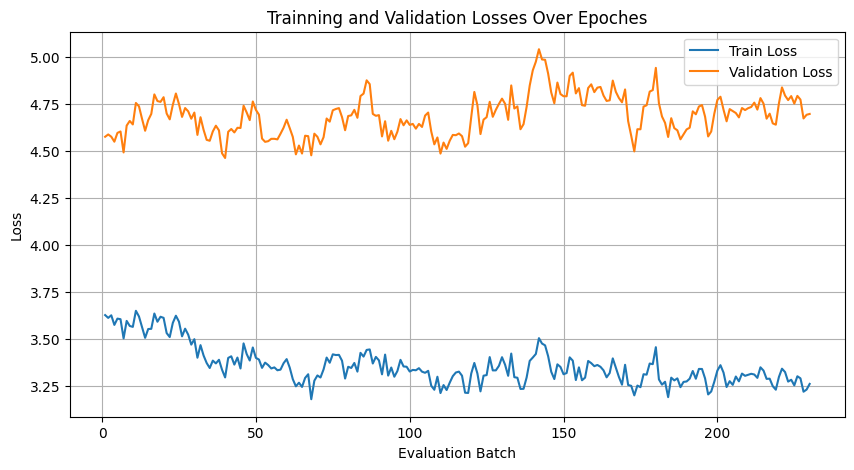

In [6]:
plt.figure(figsize=(10, 5))
plt.plot(df['epoch'], df['train_loss'], label="Train Loss")
plt.plot(df['epoch'], df['val_loss'], label="Validation Loss")
plt.xlabel("Evaluation Batch")
plt.ylabel("Loss")
plt.title("Trainning and Validation Losses Over Epoches")
plt.legend()
plt.grid()
#plt.show()
plt.savefig(checkpoint_dir / "fine-tuning.pdf")